# Winning model inference and evaluation

In [2]:
# ── Cell 1 — Imports & Setup ───────────────────────────────────────────────
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib
import mlflow
import matplotlib.pyplot as plt
import shap


mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("scotiabank_ml")

FEATURES = ["X1","X2","X3","X4","X6","X7","X8","X10","X11","X12",
            "X3_missing","X4_missing","X9_encoded"]
TARGET = "TARGET"

test = pd.read_csv("../data/splits/test.csv")
X_test, y_test = test[FEATURES], test[TARGET]
final_model = joblib.load("../models/ml/final_model_xgb.joblib")
y_pred = final_model.predict(X_test)

In [3]:
# ── Cell 2 — Metrics & MLflow ──────────────────────────────────────────────
test_rmse_log   = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2         = r2_score(y_test, y_pred)
test_mae_log    = mean_absolute_error(y_test, y_pred)
test_rmse_ogscale = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred)))
test_mae_ogscale  = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))

with mlflow.start_run(run_name="xgboost_final_test_eval"):
    mlflow.log_metric("test_rmse_log",   test_rmse_log)
    mlflow.log_metric("test_mae_log",    test_mae_log)
    mlflow.log_metric("test_r2",         test_r2)
    mlflow.log_metric("test_rmse_ogscale", test_rmse_ogscale)
    mlflow.log_metric("test_mae_ogscale",  test_mae_ogscale)

print(f"RMSE (log):   {test_rmse_log:.4f}")
print(f"MAE  (log):   {test_mae_log:.4f}")
print(f"R²:           {test_r2:.4f}")
print(f"RMSE (ogscale): {test_rmse_ogscale:.0f}")
print(f"MAE  (ogscale): {test_mae_ogscale:.0f}")

🏃 View run xgboost_final_test_eval at: http://127.0.0.1:5000/#/experiments/2/runs/526d01c45ca44881a47cac36d1b68902
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2
RMSE (log):   0.5008
MAE  (log):   0.3913
R²:           0.3953
RMSE (ogscale): 4808
MAE  (ogscale): 3122


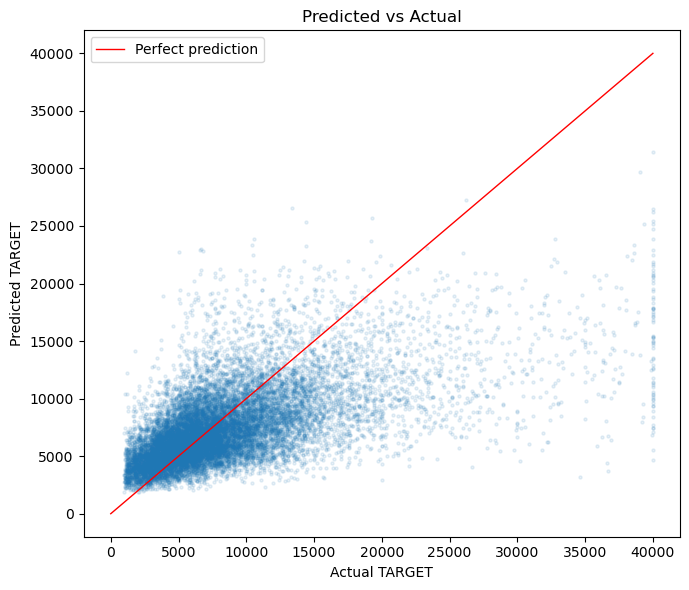

In [8]:
# ── Cell 3 — Predicted vs Actual ──────────────────────────────────────────
actual_ogscale = np.expm1(y_test)
pred_ogscale   = np.expm1(y_pred)

plt.figure(figsize=(7, 6))
plt.scatter(actual_ogscale, pred_ogscale, alpha=0.1, s=5)
plt.plot([0, 40000], [0, 40000], color="red", linewidth=1, label="Perfect prediction")
plt.xlabel("Actual TARGET")
plt.ylabel("Predicted TARGET")
plt.title("Predicted vs Actual")
plt.legend()
plt.tight_layout()
plt.show()

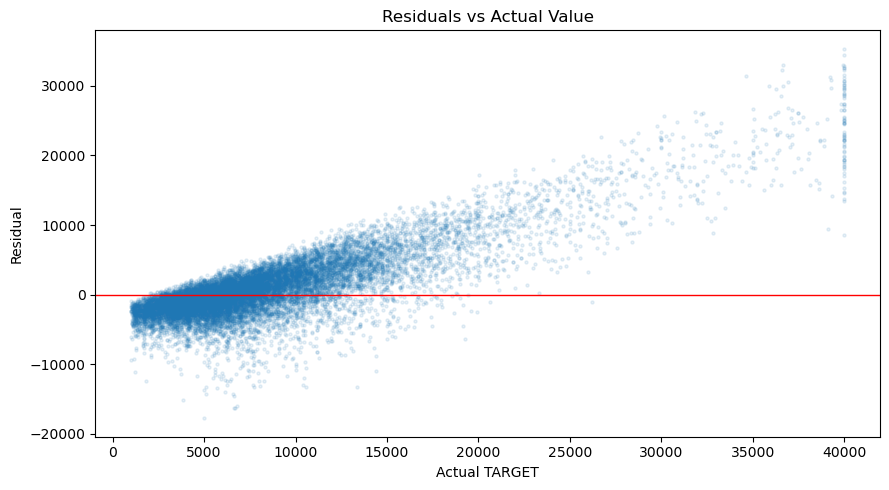

In [9]:
# ── Cell 4 — Residuals vs Actual ──────────────────────────────────────────
residuals = actual_ogscale - pred_ogscale

plt.figure(figsize=(9, 5))
plt.scatter(actual_ogscale, residuals, alpha=0.1, s=5)
plt.axhline(0, color="red", linewidth=1)
plt.xlabel("Actual TARGET")
plt.ylabel("Residual")
plt.title("Residuals vs Actual Value")
plt.tight_layout()
plt.show()

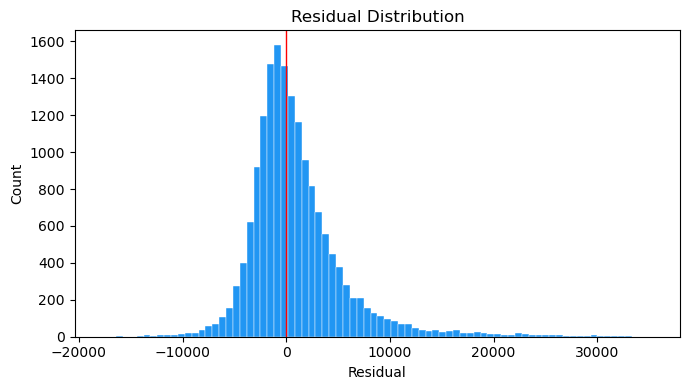

Mean residual:   979
Median residual: 109


In [10]:
# ── Cell 5 — Residual Distribution ────────────────────────────────────────
plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=80, color="#2196F3", edgecolor="white", linewidth=0.3)
plt.axvline(0, color="red", linewidth=1)
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("Residual Distribution")
plt.tight_layout()
plt.show()

print(f"Mean residual:   {residuals.mean():.0f}")
print(f"Median residual: {residuals.median():.0f}")

MAE by quartile:
segment
Q1    2074.405182
Q2    1721.807746
Q3    2221.405563
Q4    6471.779991
Name: abs_residual, dtype: float64


C:\Users\IRVIN\AppData\Local\Temp\ipykernel_19660\3944050898.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quartile_mae = eval_df.groupby("segment")["abs_residual"].mean()


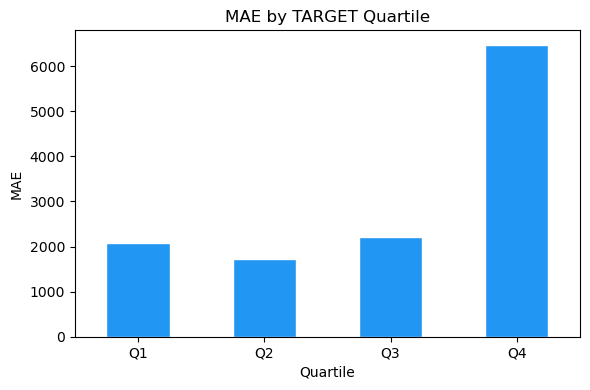

In [11]:
# ── Cell 6 — MAE by Quartile ──────────────────────────────────────────────
eval_df = pd.DataFrame({"actual": actual_ogscale, "abs_residual": residuals.abs()})
eval_df["segment"] = pd.qcut(eval_df["actual"], q=4, labels=["Q1","Q2","Q3","Q4"])
quartile_mae = eval_df.groupby("segment")["abs_residual"].mean()

print("MAE by quartile:")
print(quartile_mae)

quartile_mae.plot(kind="bar", figsize=(6, 4), color="#2196F3", edgecolor="white")
plt.title("MAE by TARGET Quartile")
plt.xlabel("Quartile")
plt.ylabel("MAE")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

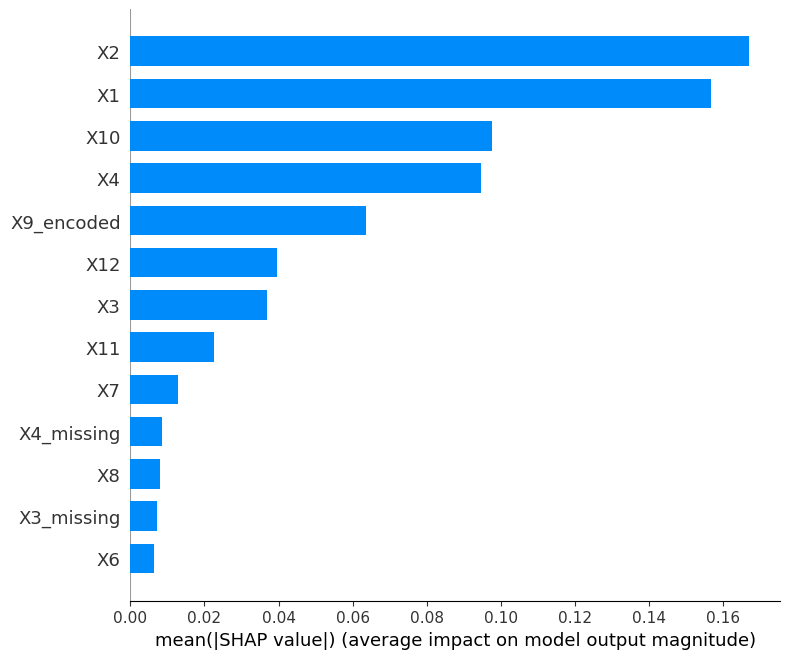

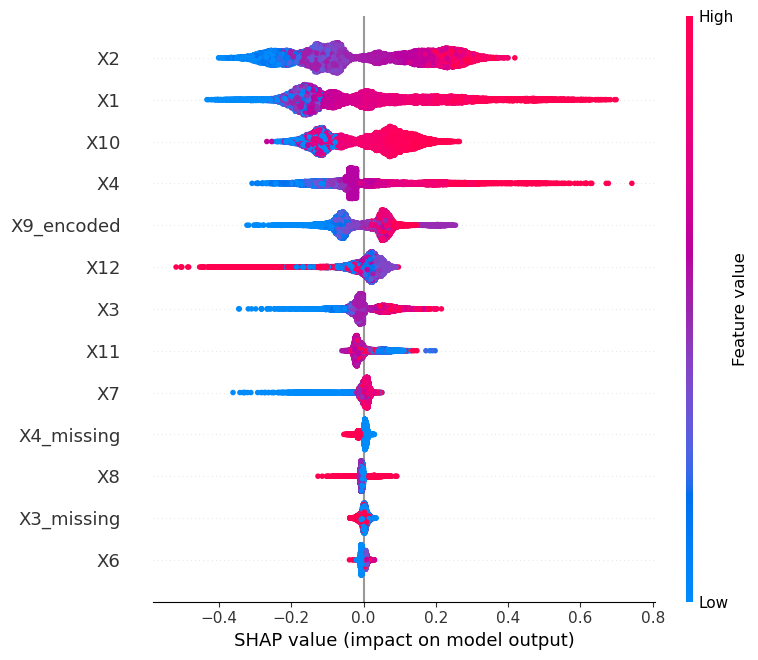

In [ ]:
# ── Cell 7 — SHAP Values ──────────────────────────────────────────────────
explainer  = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

# Global feature importance
shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)

# Beeswarm — direction + magnitude
shap.summary_plot(shap_values, X_test, show=True)
